## Boundray point VAE

In [1]:
import numpy as np
import torch
from torch import optim
from torch.utils.data import DataLoader, TensorDataset

from models.BPResVAE import BPResVAE
from utils.load_bp import load_from_dir
from copy import deepcopy
from matplotlib import pyplot as plt
from utils.generate import generate_data
from utils.visualize import contour_to_binary, contour_to_scatter, make_grid, visualize_latent_space
from torch.utils.tensorboard import SummaryWriter
import random
import time

In [2]:
img_dir = "data/img/BW fish"

bp_np = load_from_dir(img_dir, 100, 25)
print(bp_np.shape)

Loading BW1.jpg
Loading BW10.jpg
Loading BW11.jpg
Loading BW12.jpg
Loading BW13.jpg
Loading BW15.jpg
Loading BW16.jpg
Loading BW17.jpg
Loading BW18.jpg
Loading BW19.jpg
Loading BW2.jpg
Loading BW20.jpg
Loading BW21.jpg
Loading BW22.jpg
Loading BW23.jpg
Loading BW24.jpg
Loading BW25.jpg
Loading BW3.jpg
Loading BW4.jpg
Loading BW5.jpg
Loading BW6.jpg
Loading BW7.jpg
Loading BW8.jpg
Loading BW9.jpg
(24, 100, 2)


In [3]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
MODEL_SAVE_PATH = "checkpoints/BPResVAE_fish.pth"
TB_PATH = "runs/BPResVAE_fish"
TB_COMMENT = ''
SEED = 717

INPUT_DIM = 200  # Adjusted input dimension to match your complex data
H_DIM = 1000
Z_DIM = 2
H_LAYERS = [2, 2, 2]

NUM_EPOCHS = 100000
BATCH_SIZE = 64  # Adjusted batch size
LR_RATE = 1e-5  # smaller learning rate
KL_RATE = 0.25

random.seed(SEED)
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
# torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = False

In [4]:
bp_tensor = torch.tensor(bp_np).to(dtype=torch.float64)

train_data = TensorDataset(bp_tensor)
train_loader = DataLoader(
    dataset=train_data, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True
)

## Init model
model = BPResVAE(
    input_dim=INPUT_DIM,
    hidden_dim=H_DIM,
    hidden_layers=H_LAYERS,
    latent_dim=Z_DIM,
    device=DEVICE,
)
model.to(dtype=torch.float64)
model.initial()
# model.load_state_dict(torch.load(MODEL_SAVE_PATH, weights_only=True))

## Load model
# model = torch.load('VAE_theta+bias1.pth')

optimizer = optim.Adam(
    model.parameters(), lr=LR_RATE, weight_decay=1e-5, betas=(0.5, 0.999)
)
# scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10000], gamma=0.5)

# model.to(DEVICE)

loader_size = len(train_loader)
loss_list_dict = {}
best_loss = 1e9

In [5]:
writer = SummaryWriter(TB_PATH + (TB_COMMENT or time.strftime("%Y-%m-%d %H:%M:%S", time.localtime())))

model.train()

for epoch in range(NUM_EPOCHS):
    for i, [input_data] in enumerate(train_loader):
        input_data = input_data.to(DEVICE, dtype=torch.float64).view(
            input_data.shape[0], INPUT_DIM
        )
        x_reconstructed, mu, logvar = model(input_data)

        # Compute loss
        kl_rate = KL_RATE
        loss_dict = model.loss(x_reconstructed, input_data, mu, logvar, kl_rate)

        # Backprop
        optimizer.zero_grad()
        loss_dict["loss"].backward()
        optimizer.step()

        # Accumulate losses
        for k, v in loss_dict.items():
            if k not in loss_list_dict:
                loss_list_dict[k] = np.zeros(loader_size)
            loss_list_dict[k][i] = v.item()

    # Log to TensorBoard (average losses for the epoch)
    for k, v in loss_list_dict.items():
        avg_loss = v.mean()
        writer.add_scalar(f'Loss/{k}', avg_loss, epoch)

    if best_loss > loss_dict["loss"].item():
        best_loss = loss_dict["loss"].item()
        print(
            f"Best epoch {epoch}/{NUM_EPOCHS} | {', '.join([f'{k}: {v.mean():.4f}' for k, v in loss_list_dict.items()])}"
        )
        best_params = deepcopy(model.state_dict())

    if epoch % 100 == 0:
        print(
            f"Epoch {epoch}/{NUM_EPOCHS} | {', '.join([f'{k}: {v.mean():.4f}' for k, v in loss_list_dict.items()])}"
        )

model.load_state_dict(best_params)
torch.save(best_params, MODEL_SAVE_PATH)
writer.close()


Best epoch 0/100000 | loss: 422.0742, recon_loss: 417.0064, kl_loss: 20.2713
Epoch 0/100000 | loss: 422.0742, recon_loss: 417.0064, kl_loss: 20.2713
Best epoch 1/100000 | loss: 335.5675, recon_loss: 331.8895, kl_loss: 14.7121
Best epoch 2/100000 | loss: 322.7854, recon_loss: 318.9056, kl_loss: 15.5191
Best epoch 3/100000 | loss: 270.4800, recon_loss: 260.2293, kl_loss: 41.0029
Best epoch 5/100000 | loss: 204.1773, recon_loss: 198.6191, kl_loss: 22.2326
Best epoch 6/100000 | loss: 190.8487, recon_loss: 186.2551, kl_loss: 18.3745
Best epoch 7/100000 | loss: 139.5024, recon_loss: 134.9571, kl_loss: 18.1811
Best epoch 8/100000 | loss: 133.1194, recon_loss: 128.4745, kl_loss: 18.5795
Best epoch 9/100000 | loss: 107.0353, recon_loss: 102.1578, kl_loss: 19.5101
Best epoch 10/100000 | loss: 98.2945, recon_loss: 93.1472, kl_loss: 20.5895
Best epoch 11/100000 | loss: 85.2254, recon_loss: 79.8517, kl_loss: 21.4949
Best epoch 12/100000 | loss: 70.9780, recon_loss: 65.3620, kl_loss: 22.4641
Best ep

Encode-decode

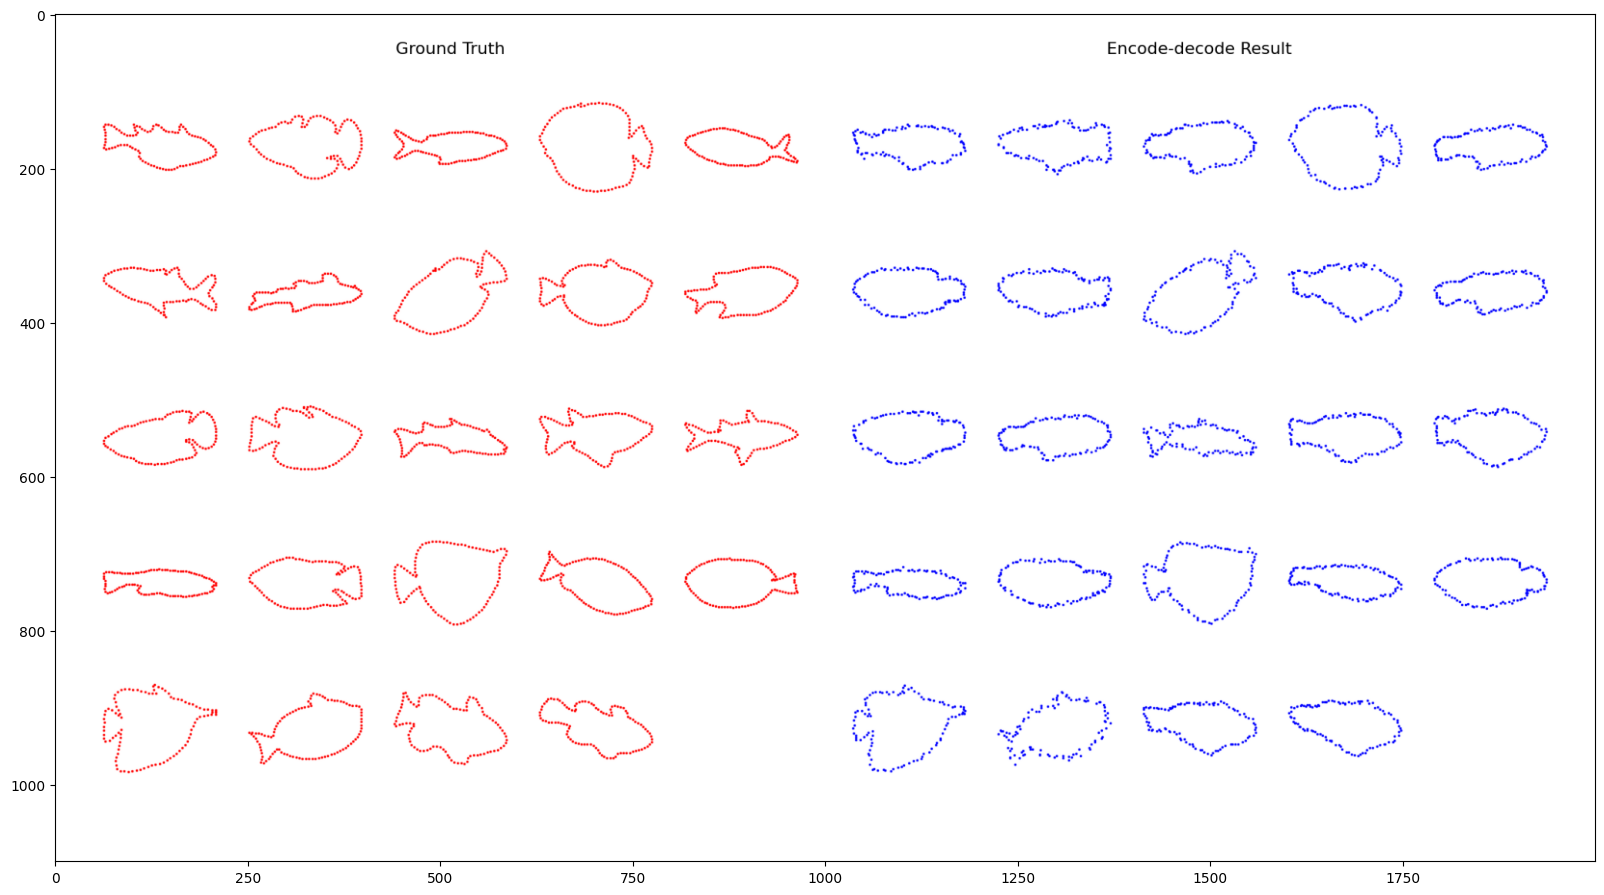

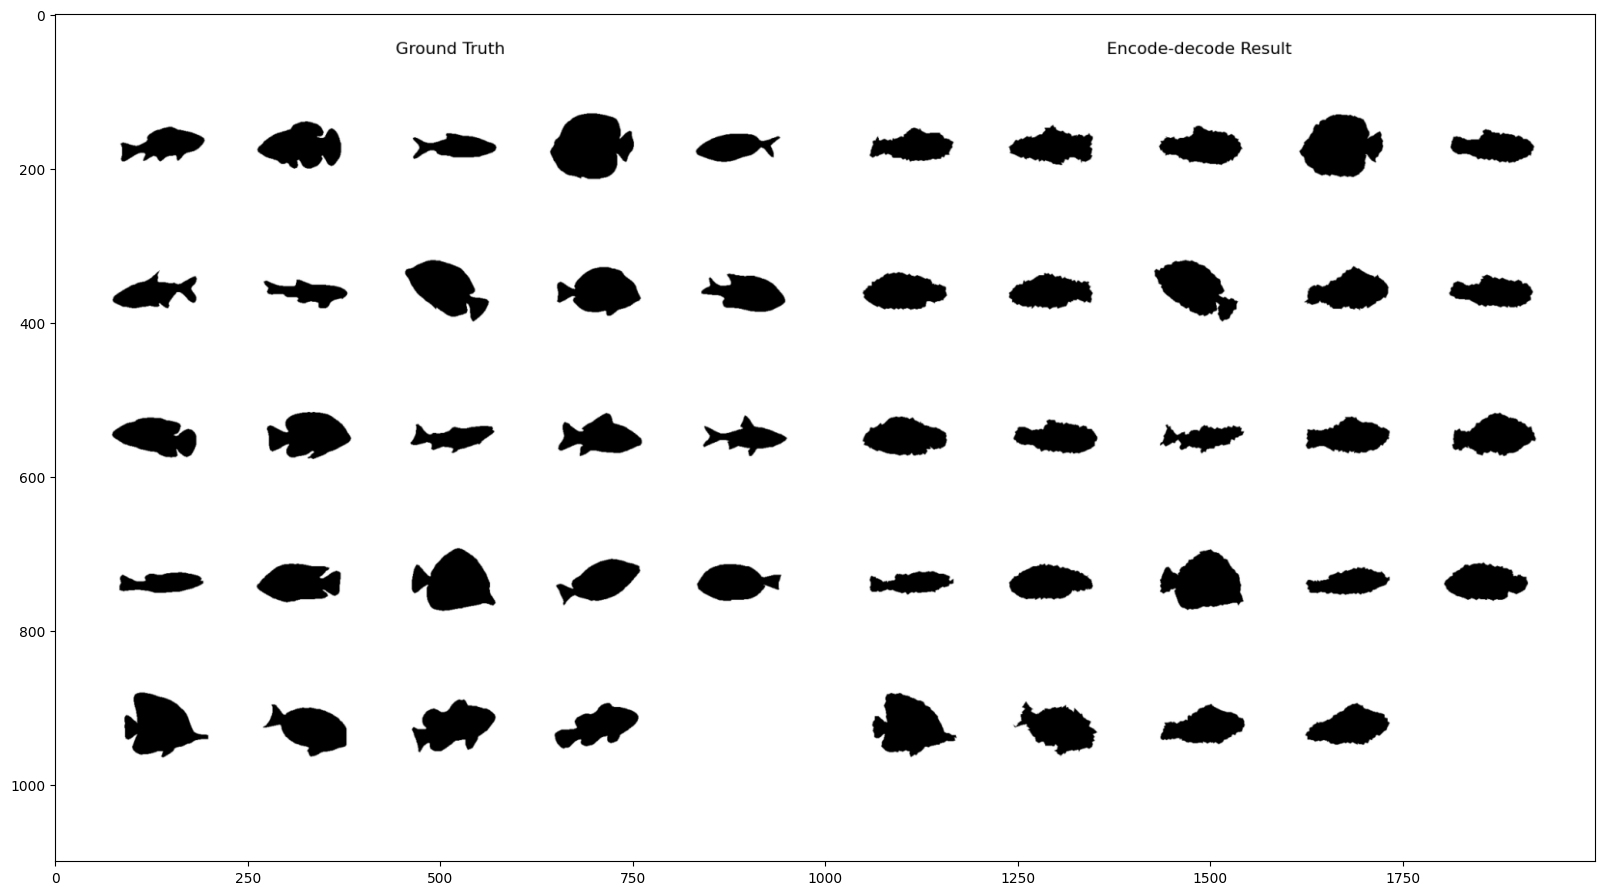

In [14]:
n = bp_tensor.shape[0]
generated_contour, _, _ = model(
    bp_tensor.to(DEVICE, dtype=torch.float64).view(n, INPUT_DIM)
)
generated_contour = generated_contour.cpu().detach()
generated_contour = model.reconstruct(generated_contour).numpy()

ground_truth_contour = bp_tensor.cpu().numpy()

generated_images = [
    contour_to_scatter(contour, color='b', figsize=(2,2), pointsize=2) for contour in generated_contour
]
ground_truth_images = [
    contour_to_scatter(contour, color='r', figsize=(2,2), pointsize=2) for contour in ground_truth_contour
]
ground_truth_grid = make_grid(ground_truth_images, rows=5, title="Ground Truth", figsize=(10,11))
generated_grid = make_grid(generated_images, rows=5, title="Encode-decode Result", figsize=(10,11))
combined_grid = make_grid([ground_truth_grid, generated_grid], rows=1, figsize=(20,11))
plt.figure(figsize=(20, 11))
plt.imshow(combined_grid)

generated_images = [
    contour_to_binary(contour, rate=0.65) for contour in generated_contour
]
ground_truth_images = [
    contour_to_binary(contour, rate=0.65) for contour in ground_truth_contour
]
ground_truth_grid = make_grid(ground_truth_images, rows=5, title="Ground Truth", figsize=(10, 11))
generated_grid = make_grid(generated_images, rows=5, title="Encode-decode Result", figsize=(10, 11))
combined_grid = make_grid([ground_truth_grid, generated_grid], rows=1, figsize=(20, 11))
plt.figure(figsize=(20, 11))
plt.imshow(combined_grid)
plt.show()

Random Generation

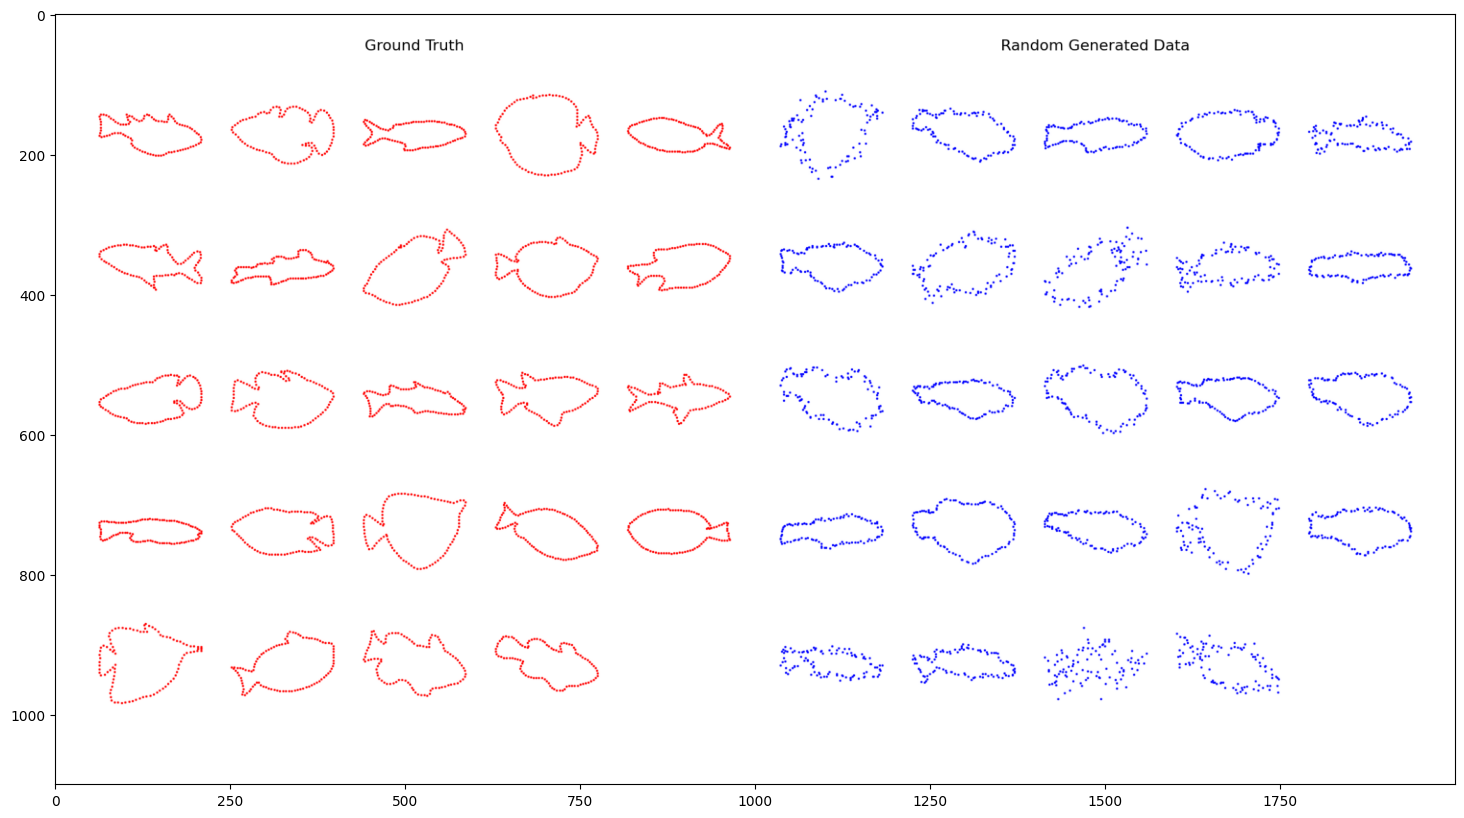

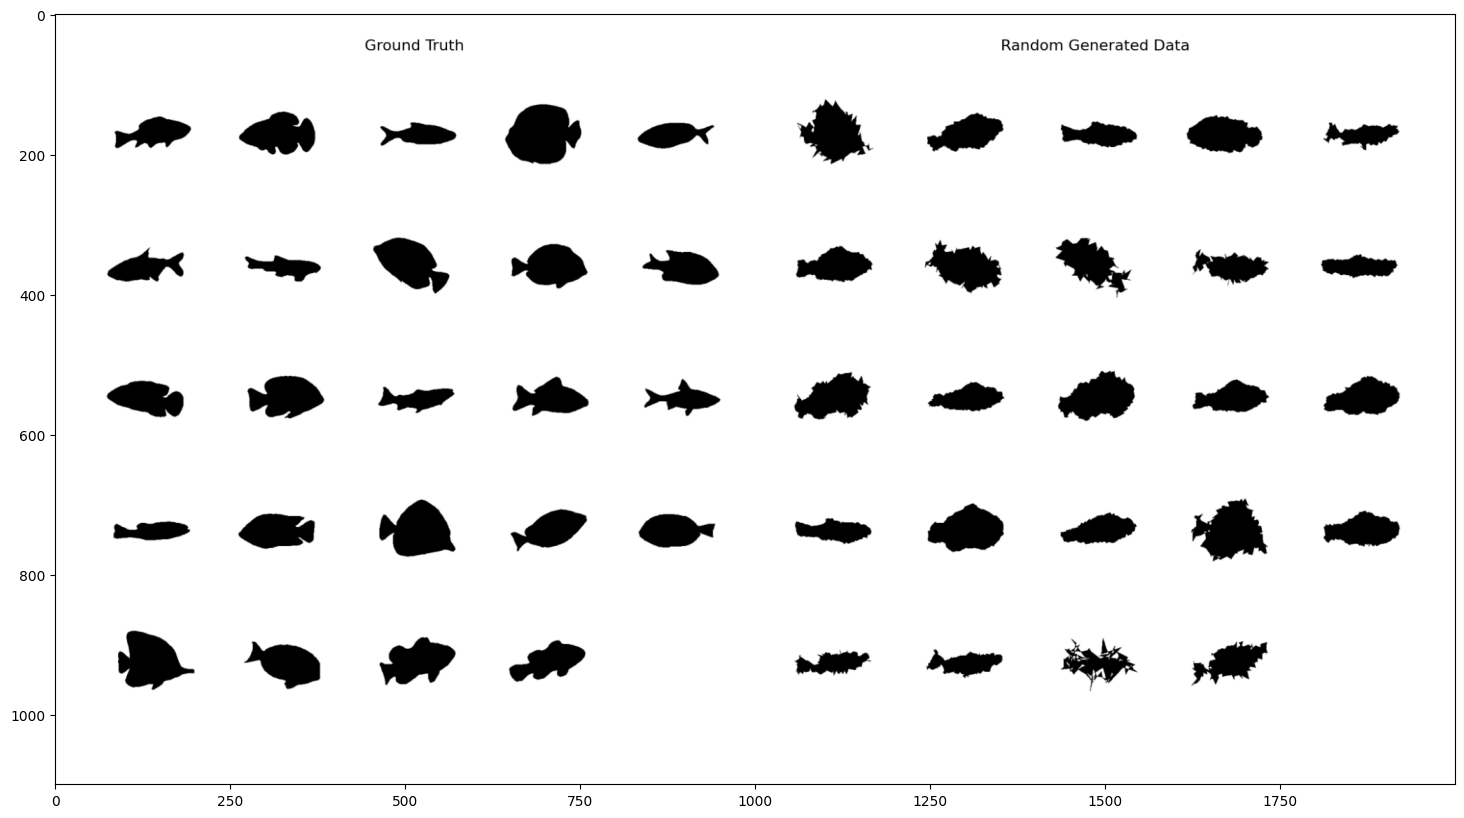

In [13]:
n = bp_tensor.shape[0]
generated_contour, _ = generate_data(model, num=n, k=2)
generated_contour = model.reconstruct(generated_contour).numpy()

ground_truth_contour = bp_tensor.cpu().numpy()

generated_images = [
    contour_to_scatter(contour, color='b', figsize=(2,2), pointsize=2) for contour in generated_contour
]
ground_truth_images = [
    contour_to_scatter(contour, color='r', figsize=(2,2), pointsize=2) for contour in ground_truth_contour
]
ground_truth_grid = make_grid(ground_truth_images, rows=5, title="Ground Truth", figsize=(10, 11))
generated_grid = make_grid(generated_images, rows=5, title="Random Generated Data", figsize=(10, 11))
combined_grid = make_grid([ground_truth_grid, generated_grid], rows=1, figsize=(20, 11))
plt.figure(figsize=(20, 10))
plt.imshow(combined_grid)

generated_images = [
    contour_to_binary(contour, rate=0.65) for contour in generated_contour
]
ground_truth_images = [
    contour_to_binary(contour, rate=0.65) for contour in ground_truth_contour
]
ground_truth_grid = make_grid(ground_truth_images, rows=5, title="Ground Truth", figsize=(10, 11))
generated_grid = make_grid(generated_images, rows=5, title="Random Generated Data", figsize=(10, 11))
combined_grid = make_grid([ground_truth_grid, generated_grid], rows=1, figsize=(20, 11))
plt.figure(figsize=(20, 10))
plt.imshow(combined_grid)

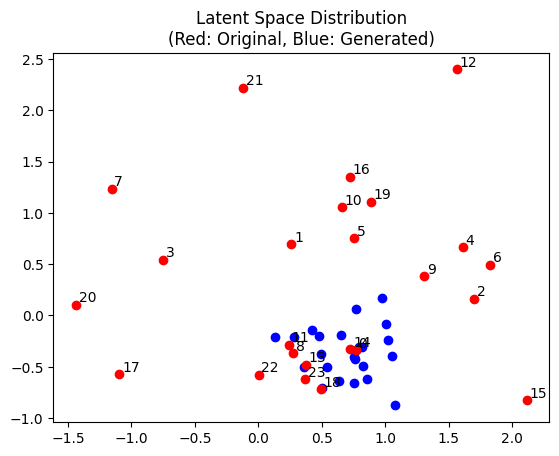

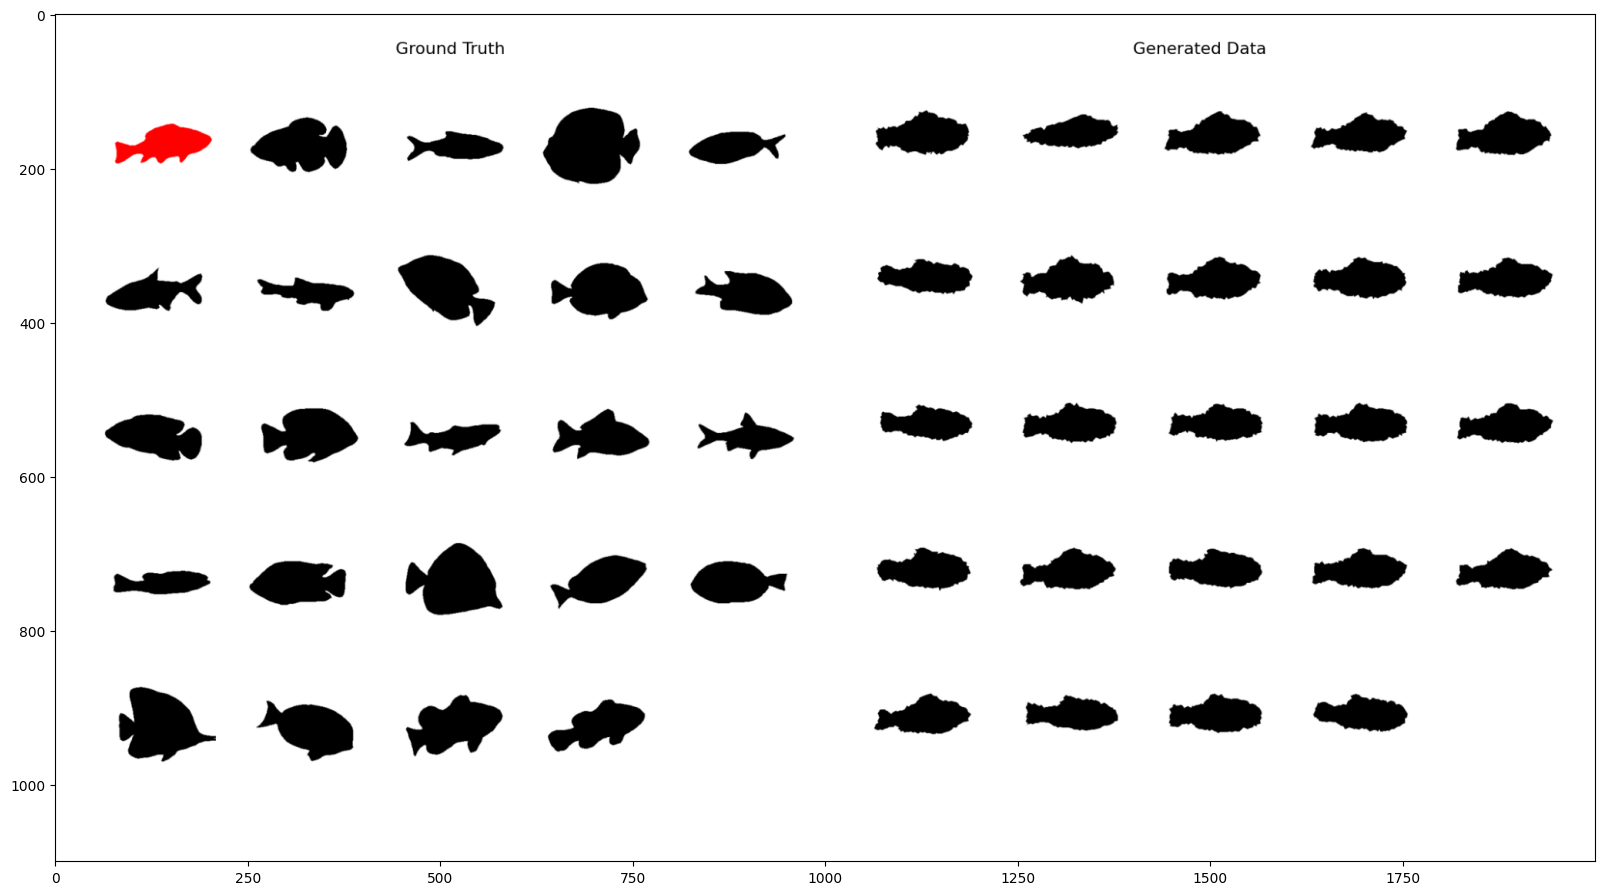

In [8]:
# from utils.generate import generate_data

ref_num = 0
var = 0.2
mu, log_var = model.encode(bp_tensor.to(DEVICE, dtype=torch.float64).view(n, INPUT_DIM))
z_ground_truth = mu + log_var.exp().sqrt()
mu_vals = torch.repeat_interleave(z_ground_truth[ref_num].view(1, -1), n, dim=0)
generated_contour, z_generated = generate_data(
    model, num=n, mu_vals=mu_vals, k=var
)
generated_contour = generated_contour.detach().cpu().numpy()

visualize_latent_space(z_ground_truth, z_generated)


generated_images = [contour_to_binary(contour) for contour in generated_contour]
ground_truth_images = [contour_to_binary(contour, color=(255,0,0) if i == ref_num else (0, 0, 0)) for i, contour in enumerate(ground_truth_contour)]

ground_truth_grid = make_grid(ground_truth_images, rows=5, title='Ground Truth', figsize=(10, 11))
generated_grid = make_grid(generated_images, rows=5, title='Generated Data', figsize=(10, 11))
combined_grid = make_grid([ground_truth_grid, generated_grid], rows=1, figsize=(20, 11))
plt.figure(figsize=(20, 11))
plt.imshow(combined_grid)